## Import Packages

In [33]:
import pandas as pd
import sqlite3
import time
import matplotlib.pyplot as plt
import seaborn as sns

## Read Data

In [34]:
# Load your dataset
dataset_file = 'data/best-selling-books.csv'
data = pd.read_csv(dataset_file)

# Rename columns to SQL-friendly names
data.rename(columns={"Author(s)": "Author_s"}, inplace=True)

In [35]:
data

,Book,Author_s,Original language,First published,Approximate sales in millions,Genre
0,A Tale of Two Cities,Charles Dickens,English,1859,200.0,Historical fiction
1,The Little Prince (Le Petit Prince),Antoine de Saint-Exupéry,French,1943,200.0,Novella
2,Harry Potter and the Philosopher's Stone,J. K. Rowling,English,1997,120.0,Fantasy
3,And Then There Were None,Agatha Christie,English,1939,100.0,Mystery
4,Dream of the Red Chamber (紅樓夢),Cao Xueqin,Chinese,1791,100.0,Family saga
...,...,...,...,...,...,...
169,The Goal,Eliyahu M. Goldratt,English,1984,10.0,NaN
170,Fahrenheit 451,Ray Bradbury,English,1953,10.0,NaN
171,Angela's Ashes,Frank McCourt,English,1996,10.0,NaN
172,The Story of My Experiments with Truth (સત્યના...,Mohandas Karamchand Gandhi,Gujarati,1929,10.0,NaN


## Data Exploration

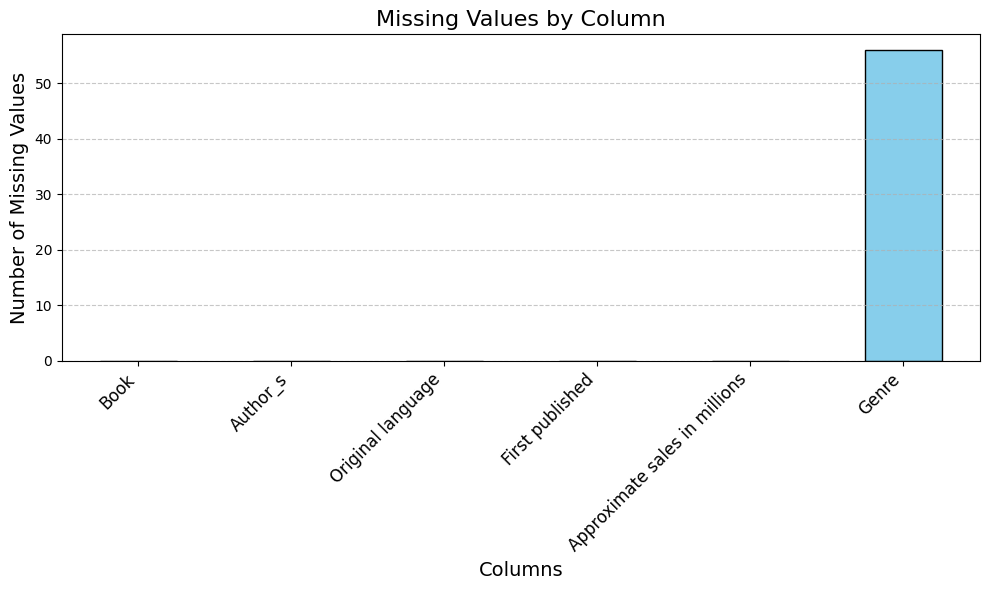

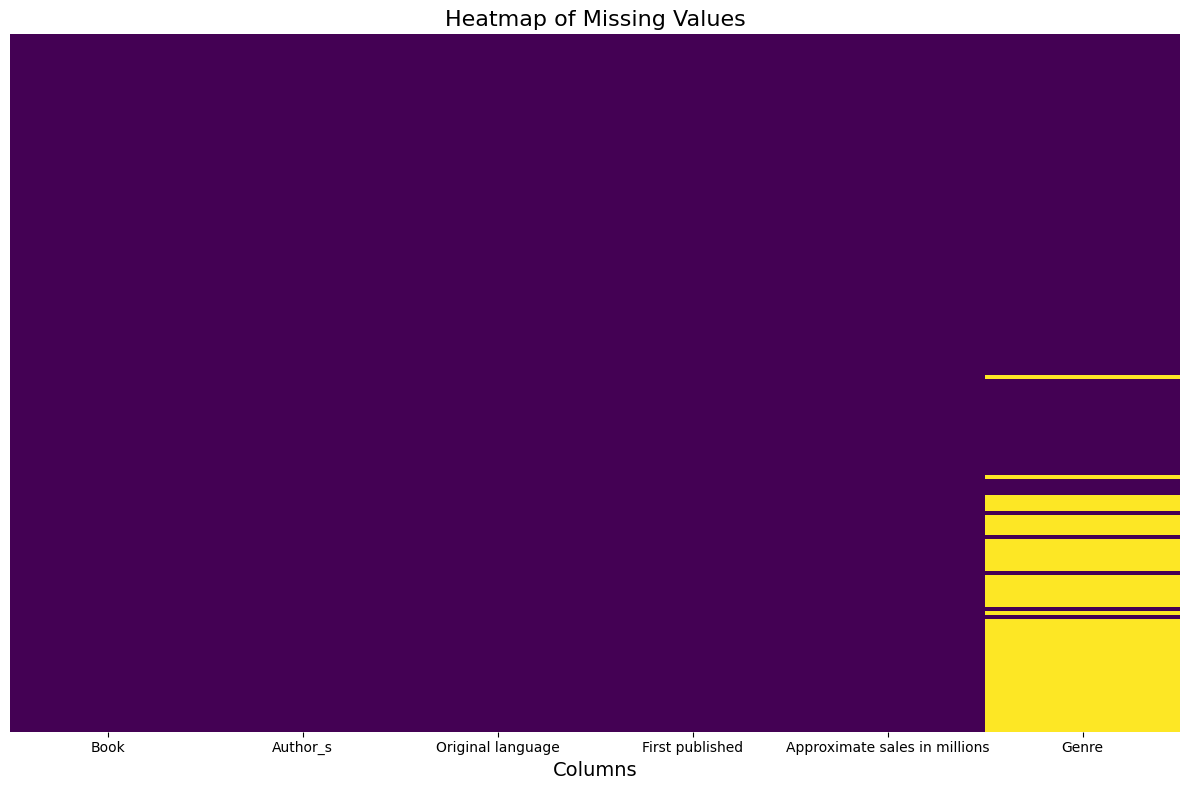

In [36]:
# Identify missing values
missing_values = data.isnull().sum()

# Create a bar chart of missing values
plt.figure(figsize=(10, 6))
missing_values.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Missing Values by Column', fontsize=16)
plt.xlabel('Columns', fontsize=14)
plt.ylabel('Number of Missing Values', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Create a heatmap to show missing values in the dataset
plt.figure(figsize=(12, 8))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Heatmap of Missing Values', fontsize=16)
plt.xlabel('Columns', fontsize=14)
plt.tight_layout()
plt.show()

In [37]:
# Convert relevant columns to appropriate types
data['Approximate sales in millions'] = pd.to_numeric(data['Approximate sales in millions'], errors='coerce')

# Drop rows with missing sales
data.dropna(subset=['Approximate sales in millions'], inplace=True)

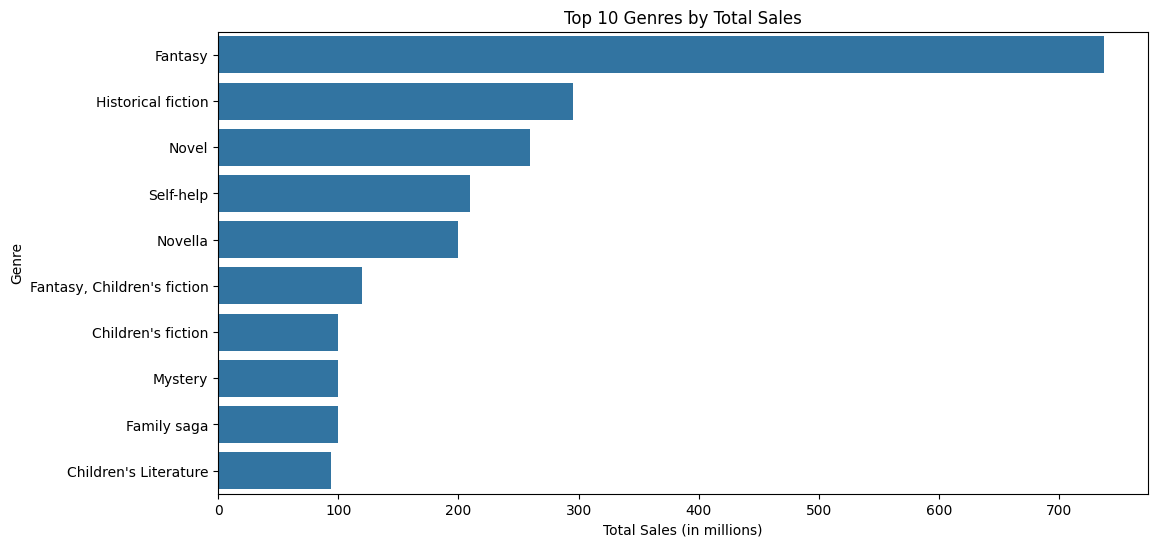

In [38]:
# Plot 1: Top 10 genres by total sales
genre_sales = data.groupby('Genre')['Approximate sales in millions'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_sales.values, y=genre_sales.index)
plt.title('Top 10 Genres by Total Sales')
plt.xlabel('Total Sales (in millions)')
plt.ylabel('Genre')
plt.show()

/var/folders/6y/r3h7z1zx71j8z2ngxj6zh3mw0000gn/T/ipykernel_22746/3911388829.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data[data['Original language'].isin(top_languages)],


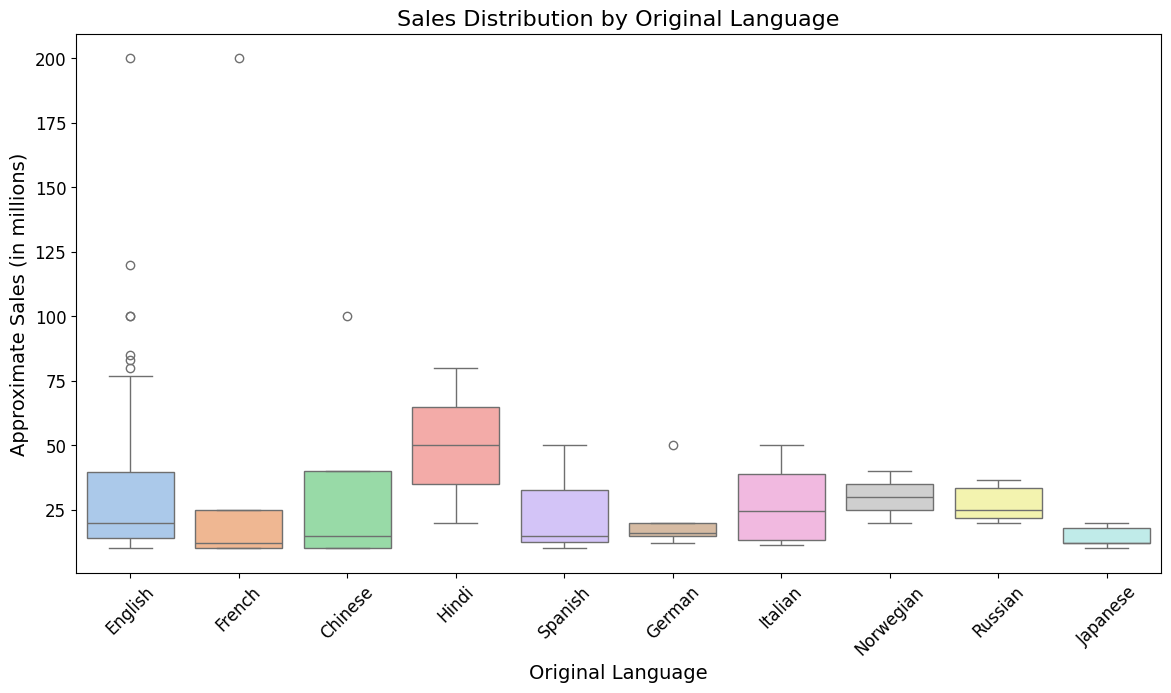

In [39]:
# Plot 2: Sales distribution by original language with colors
plt.figure(figsize=(14, 7))
top_languages = data['Original language'].value_counts().head(10).index

sns.boxplot(data=data[data['Original language'].isin(top_languages)], 
            x='Original language', 
            y='Approximate sales in millions', 
            palette="pastel")  # Add a colorful palette, e.g., "pastel"

plt.title('Sales Distribution by Original Language', fontsize=16)
plt.xlabel('Original Language', fontsize=14)
plt.ylabel('Approximate Sales (in millions)', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.show()

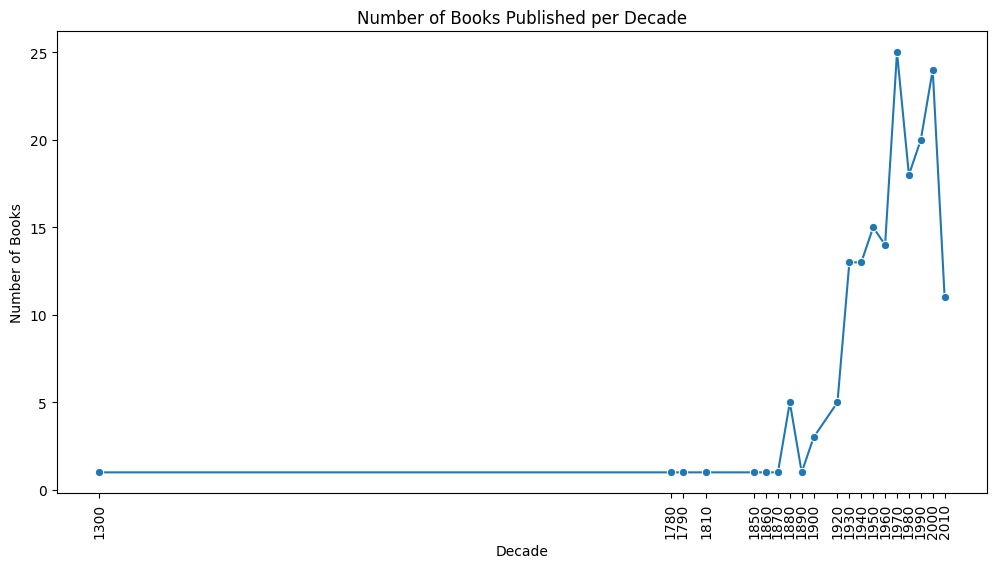

In [40]:
# Plot 3: Number of books published per decade
# Ensure 'First published' is numeric and drop invalid values
data['First published'] = pd.to_numeric(data['First published'], errors='coerce')
data = data.dropna(subset=['First published'])  # Drop rows where 'First published' is NaN
data['First published'] = data['First published'].astype(int)  # Convert to integer

# Create the Decade column
data['Decade'] = (data['First published'] // 10 * 10).astype(int)

# Count books per decade
books_per_decade = data['Decade'].value_counts().sort_index()

# Plot the data
plt.figure(figsize=(12, 6))
sns.lineplot(x=books_per_decade.index, y=books_per_decade.values, marker="o")
plt.title('Number of Books Published per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Books')
plt.xticks(books_per_decade.index, rotation=90)  # Rotate x-axis labels by 90 degrees
plt.show()

/var/folders/6y/r3h7z1zx71j8z2ngxj6zh3mw0000gn/T/ipykernel_22746/854913940.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=author_sales.values,


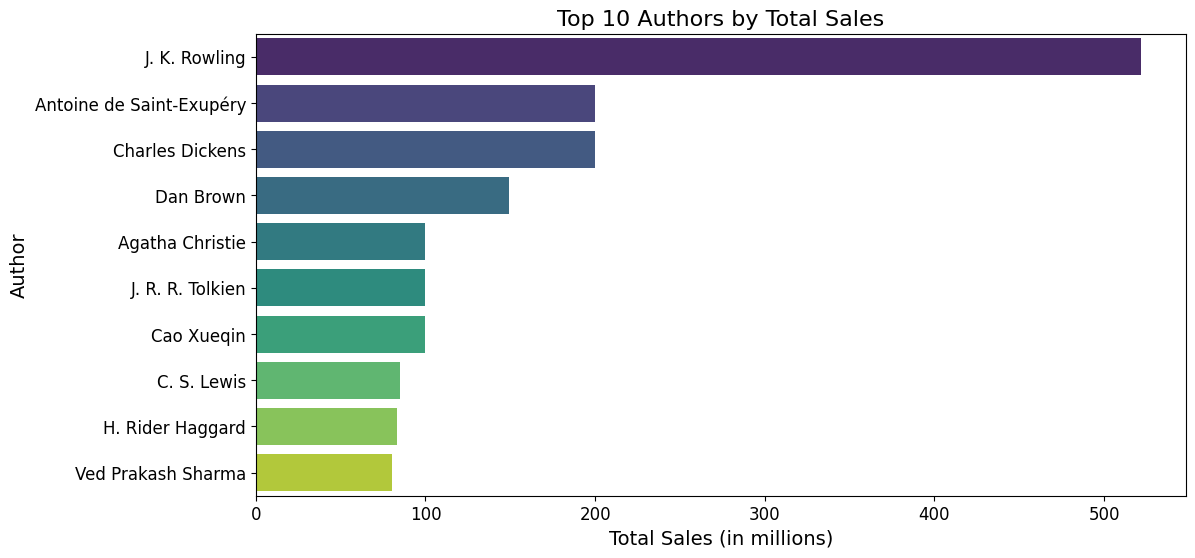

In [41]:
# Plot 5: Top 10 authors by total sales with colors
author_sales = data.groupby('Author_s')['Approximate sales in millions'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=author_sales.values, 
            y=author_sales.index, 
            palette="viridis")  # Add a colorful palette like "viridis"
plt.title('Top 10 Authors by Total Sales', fontsize=16)
plt.xlabel('Total Sales (in millions)', fontsize=14)
plt.ylabel('Author', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig('plots.png')
plt.show()

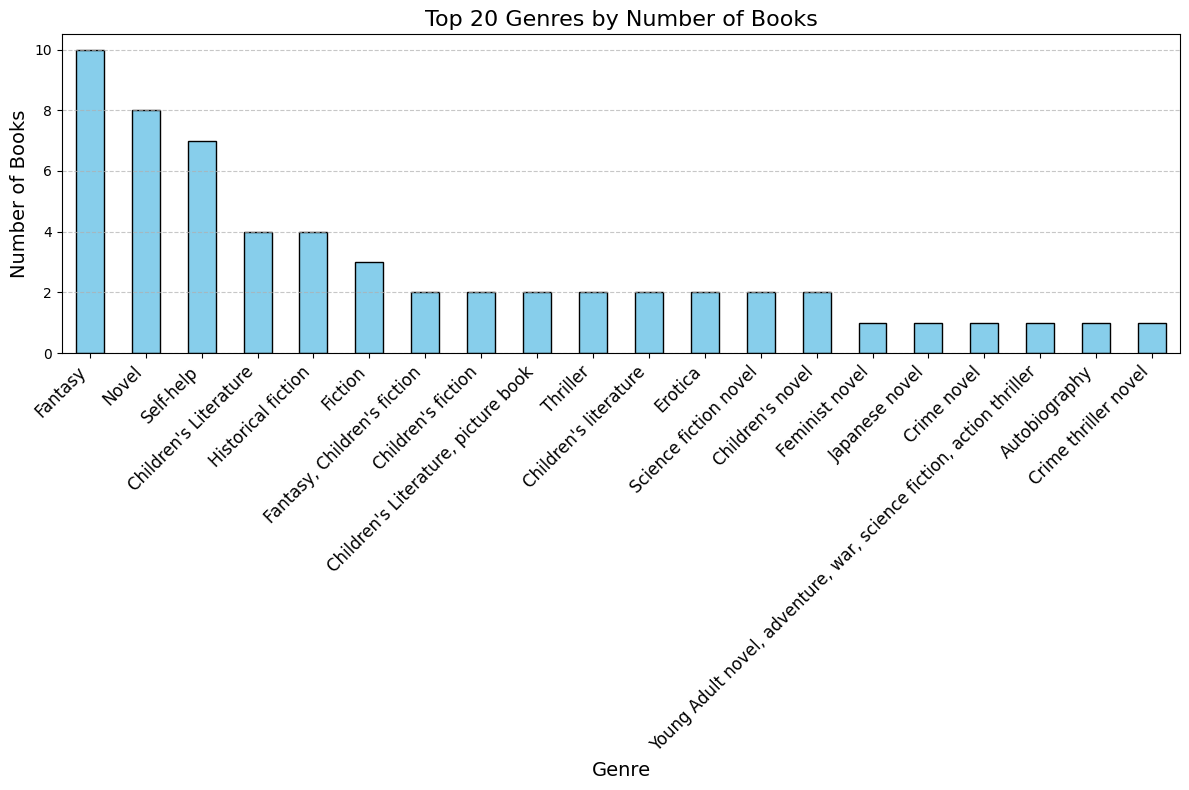

In [42]:
# Group the dataset by Genre and count the number of books in each genre
genre_counts = data['Genre'].value_counts()

# Select the top 20 genres
top_20_genres = genre_counts.head(20)

# Plot a bar chart for the top 20 genres
plt.figure(figsize=(12, 8))
top_20_genres.plot(kind='bar', color='skyblue', edgecolor='black')

# Add titles and labels
plt.title('Top 20 Genres by Number of Books', fontsize=16)
plt.xlabel('Genre', fontsize=14)
plt.ylabel('Number of Books', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)  # Rotate genre names for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

# Baseline Queries

In [43]:
# Create an in-memory SQLite database
conn = sqlite3.connect(":memory:")

# Write the dataset into a SQL table
data.to_sql("books", conn, if_exists="replace", index=False)

174

## Query 1:

Find authors who have written at least one Children's/YA book and one Fiction book

In [44]:
# Query 1: Find authors who have written at least one Children's/YA book and one Fiction book
query1 = """
SELECT DISTINCT a.first_name, a.last_name
FROM (
    SELECT
        TRIM(SUBSTR(Author_s, 1, INSTR(Author_s || ' ', ' ') - 1)) AS first_name,
        TRIM(SUBSTR(Author_s || ' ', INSTR(Author_s || ' ', ' ') + 1)) AS last_name,
        Genre
    FROM books
) a
WHERE a.Genre LIKE '%Children%'
AND EXISTS (
    SELECT 1 FROM books b
    WHERE b.Genre LIKE '%Fiction%'
      AND TRIM(SUBSTR(b.Author_s, 1, INSTR(b.Author_s || ' ', ' ') - 1)) = a.first_name
      AND TRIM(SUBSTR(b.Author_s || ' ', INSTR(b.Author_s || ' ', ' ') + 1)) = a.last_name
)
ORDER BY a.first_name, a.last_name;
"""

# Use EXPLAIN QUERY PLAN to analyze Query 1 (outside timing)
cursor = conn.cursor()
cursor.execute(f"EXPLAIN QUERY PLAN {query1}")
plan1 = cursor.fetchall()

# Print the execution plan for Query 1
print("Execution Plan for Query 1:")
for step in plan1:
    print(step)

# Measure time for Query 1 execution
start_time = time.perf_counter()
result1 = pd.read_sql_query(query1, conn)
end_time = time.perf_counter()
execution_time1 = end_time - start_time

# Print the results for Query 1
print(f"\nExecution Time for Query 1: {execution_time1:.4f} seconds")
print("\nResults for Query 1:")
print(result1)


Execution Plan for Query 1:
(7, 0, 0, 'SCAN books')
(13, 0, 0, 'CORRELATED SCALAR SUBQUERY 2')
(17, 13, 0, 'SCAN b')
(59, 0, 0, 'USE TEMP B-TREE FOR DISTINCT')

Execution Time for Query 1: 0.0130 seconds

Results for Query 1:
  first_name                                last_name
0         C.                                 S. Lewis
1      Carlo                                  Collodi
2         E.  B. White; illustrated by Garth Williams
3    Johanna                                    Spyri
4     Robert                                   Munsch


## Query 2:

Find authors who have written at least one book in every genre of J.K. Rowling

In [45]:
# Create a view for J.K. Rowling's genres (subjects)
view_creation_query = """
CREATE VIEW JK_Rowling_Genres AS
SELECT DISTINCT Genre
FROM books
WHERE Author_s = 'J. K. Rowling';
"""
conn.execute(view_creation_query)

# Query 2: Find authors who have written at least one book in every genre of J.K. Rowling
query2 = """
SELECT DISTINCT b.Author_s AS Author, 
       TRIM(SUBSTR(b.Author_s, 1, INSTR(b.Author_s || ' ', ' ') - 1)) AS First_Name,
       TRIM(SUBSTR(b.Author_s || ' ', INSTR(b.Author_s || ' ', ' ') + 1)) AS Last_Name
FROM books b
WHERE NOT EXISTS (
    SELECT g.Genre
    FROM JK_Rowling_Genres g
    WHERE g.Genre NOT IN (
        SELECT DISTINCT b2.Genre
        FROM books b2
        WHERE b2.Author_s = b.Author_s
    )
)
ORDER BY Last_Name ASC, Author DESC;
"""

# Use EXPLAIN QUERY PLAN to analyze Query 2 (outside timing)
cursor.execute(f"EXPLAIN QUERY PLAN {query2}")
plan2 = cursor.fetchall()

# Print the execution plan for Query 2
print("\nExecution Plan for Query 2:")
for step in plan2:
    print(step)

# Measure time for Query 2 execution
start_time = time.perf_counter()
result2 = pd.read_sql_query(query2, conn)
end_time = time.perf_counter()
execution_time2 = end_time - start_time

# Print the results for Query 2
print(f"\nExecution Time for Query 2: {execution_time2:.4f} seconds")
print("\nResults for Query 2:")
print(result2)


Execution Plan for Query 2:
(4, 0, 0, 'SCAN b')
(7, 0, 0, 'CORRELATED SCALAR SUBQUERY 2')
(10, 7, 0, 'CO-ROUTINE JK_Rowling_Genres')
(13, 10, 0, 'SCAN books')
(23, 10, 0, 'USE TEMP B-TREE FOR DISTINCT')
(26, 7, 0, 'SCAN g')
(30, 7, 0, 'CORRELATED LIST SUBQUERY 1')
(33, 30, 0, 'SCAN b2')
(45, 30, 0, 'USE TEMP B-TREE FOR DISTINCT')
(88, 0, 0, 'USE TEMP B-TREE FOR DISTINCT')
(89, 0, 0, 'USE TEMP B-TREE FOR ORDER BY')

Execution Time for Query 2: 0.0040 seconds

Results for Query 2:
                        Author First_Name          Last_Name
0                Richard Adams    Richard              Adams
1                  Mitch Albom      Mitch              Albom
2              Dante Alighieri      Dante          Alighieri
3              Charles Berlitz    Charles            Berlitz
4                   John Boyne       John              Boyne
5                 Ray Bradbury        Ray           Bradbury
6             Erskine Caldwell    Erskine           Caldwell
7                 Albert Ca

# Optimized Queries

## Query 1:

In [46]:
import pandas as pd
import sqlite3
import time

# Load dataset
dataset_file = 'data/best-selling-books.csv'
data = pd.read_csv(dataset_file)

# Rename columns for SQL compatibility
data.rename(columns={"Author(s)": "Author_s"}, inplace=True)

# Create SQLite in-memory database
conn = sqlite3.connect(":memory:")

# Write the dataset into a SQL table
data.to_sql("books", conn, if_exists="replace", index=False)

# Create an index for faster lookups on Genre and Author_s
conn.execute("CREATE INDEX idx_genre ON books(Genre);")
conn.execute("CREATE INDEX idx_author_s ON books(Author_s);")

# Optimized Query: Avoid correlated subquery by using a join
optimized_query = """
SELECT DISTINCT 
    TRIM(SUBSTR(a.Author_s, 1, INSTR(a.Author_s || ' ', ' ') - 1)) AS first_name,
    TRIM(SUBSTR(a.Author_s || ' ', INSTR(a.Author_s || ' ', ' ') + 1)) AS last_name
FROM books a
JOIN books b
ON TRIM(SUBSTR(a.Author_s, 1, INSTR(a.Author_s || ' ', ' ') - 1)) = TRIM(SUBSTR(b.Author_s, 1, INSTR(b.Author_s || ' ', ' ') - 1))
AND TRIM(SUBSTR(a.Author_s || ' ', INSTR(a.Author_s || ' ', ' ') + 1)) = TRIM(SUBSTR(b.Author_s || ' ', INSTR(b.Author_s || ' ', ' ') + 1))
WHERE a.Genre LIKE '%Children%'
AND b.Genre LIKE '%Fiction%'
ORDER BY first_name, last_name;
"""

# Custom iterator class for vectorized processing
class ResultIterator:
    def __init__(self, cursor, batch_size=100):
        self.cursor = cursor
        self.batch_size = batch_size

    def __iter__(self):
        return self

    def __next__(self):
        rows = self.cursor.fetchmany(self.batch_size)
        if not rows:
            raise StopIteration
        return rows

# Measure performance of the optimized query
start_time = time.perf_counter()

# Execute the optimized query
cursor = conn.cursor()
cursor.execute(optimized_query)

# Use the custom iterator to process results
iterator = ResultIterator(cursor)
all_results = []
for batch in iterator:
    all_results.extend(batch)

end_time = time.perf_counter()
execution_time = end_time - start_time

# Convert results to DataFrame for display
columns = ["first_name", "last_name"]
results_df = pd.DataFrame(all_results, columns=columns)

# Print execution time and results
print(f"Execution Time for Optimized Query: {execution_time:.4f} seconds")
print("\nResults:")
print(results_df)

# Close the database connection
conn.close()

Execution Time for Optimized Query: 0.0004 seconds

Results:
  first_name                                last_name
0         C.                                 S. Lewis
1      Carlo                                  Collodi
2         E.  B. White; illustrated by Garth Williams
3    Johanna                                    Spyri
4     Robert                                   Munsch


## Query 2:

In [47]:
# Create SQLite in-memory database
conn = sqlite3.connect(":memory:")

# Write the dataset into a SQL table
data.to_sql("books", conn, if_exists="replace", index=False)

# Create indices for faster lookups
conn.execute("CREATE INDEX idx_author_s ON books(Author_s);")
conn.execute("CREATE INDEX idx_genre ON books(Genre);")

# Create a materialized table instead of a view for J.K. Rowling's genres
conn.execute("""
CREATE TABLE JK_Rowling_Genres AS
SELECT DISTINCT Genre
FROM books
WHERE Author_s = 'J. K. Rowling';
""")

# Optimized Query 2: Use JOIN instead of NOT EXISTS
optimized_query2 = """
SELECT DISTINCT 
    b.Author_s AS Author, 
    TRIM(SUBSTR(b.Author_s, 1, INSTR(b.Author_s || ' ', ' ') - 1)) AS First_Name,
    TRIM(SUBSTR(b.Author_s || ' ', INSTR(b.Author_s || ' ', ' ') + 1)) AS Last_Name
FROM books b
LEFT JOIN JK_Rowling_Genres g ON g.Genre NOT IN (
    SELECT DISTINCT b2.Genre
    FROM books b2
    WHERE b2.Author_s = b.Author_s
)
WHERE g.Genre IS NULL
ORDER BY Last_Name ASC, Author DESC;
"""

# Custom iterator for efficient result processing
class ResultIterator:
    def __init__(self, cursor, batch_size=100):
        self.cursor = cursor
        self.batch_size = batch_size

    def __iter__(self):
        return self

    def __next__(self):
        rows = self.cursor.fetchmany(self.batch_size)
        if not rows:
            raise StopIteration
        return rows

# Measure time for optimized Query 2
cursor = conn.cursor()
cursor.execute(f"EXPLAIN QUERY PLAN {optimized_query2}")
plan2 = cursor.fetchall()

# Print the execution plan
print("\nExecution Plan for Optimized Query 2:")
for step in plan2:
    print(step)

# Measure execution time
start_time = time.perf_counter()

# Execute the query
cursor.execute(optimized_query2)
iterator = ResultIterator(cursor)

# Process the results using the custom iterator
all_results = []
for batch in iterator:
    all_results.extend(batch)

end_time = time.perf_counter()
execution_time2 = end_time - start_time

# Convert results to DataFrame for display
columns = ["Author", "First_Name", "Last_Name"]
results_df = pd.DataFrame(all_results, columns=columns)

# Print execution time and results
print(f"\nExecution Time for Optimized Query 2: {execution_time2:.4f} seconds")
print("\nResults:")
print(results_df)

# Close the database connection
conn.close()


Execution Plan for Optimized Query 2:
(5, 0, 0, 'SCAN b USING COVERING INDEX idx_author_s')
(7, 0, 0, 'SCAN g LEFT-JOIN')
(11, 0, 0, 'CORRELATED LIST SUBQUERY 1')
(15, 11, 0, 'SEARCH b2 USING INDEX idx_author_s (Author_s=?)')
(28, 11, 0, 'USE TEMP B-TREE FOR DISTINCT')
(73, 0, 0, 'USE TEMP B-TREE FOR DISTINCT')
(74, 0, 0, 'USE TEMP B-TREE FOR ORDER BY')

Execution Time for Optimized Query 2: 0.0008 seconds

Results:
                        Author First_Name          Last_Name
0                Richard Adams    Richard              Adams
1                  Mitch Albom      Mitch              Albom
2              Dante Alighieri      Dante          Alighieri
3              Charles Berlitz    Charles            Berlitz
4                   John Boyne       John              Boyne
5                 Ray Bradbury        Ray           Bradbury
6             Erskine Caldwell    Erskine           Caldwell
7                 Albert Camus     Albert              Camus
8                   Jung Chang

### Results Plot

**Disclaimer: Execution times may vary depending on hardware and other conditions.**


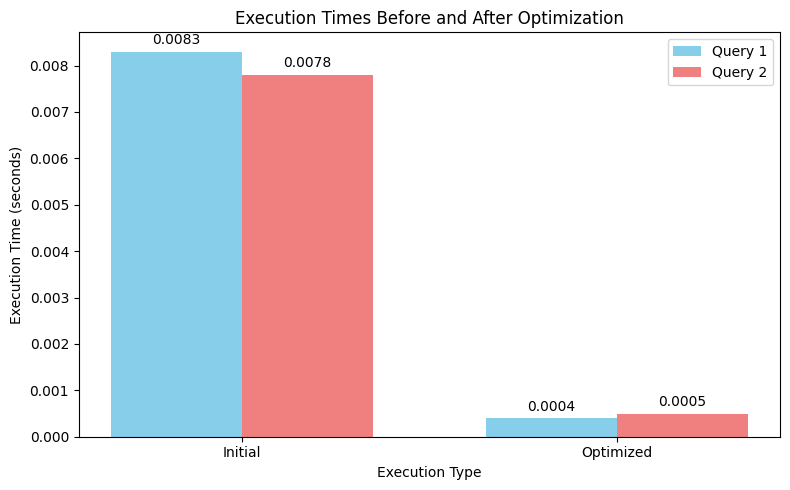

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data for execution times
categories = ["Initial", "Optimized"]
query1_times = [0.0083, 0.0004]
query2_times = [0.0078, 0.0005]

# X-axis positions for groups
x = np.arange(len(categories))

# Bar width
bar_width = 0.35

# Create grouped bar chart
plt.figure(figsize=(8, 5))
plt.bar(x - bar_width / 2, query1_times, width=bar_width, label='Query 1', color='skyblue')
plt.bar(x + bar_width / 2, query2_times, width=bar_width, label='Query 2', color='lightcoral')

# Add labels and annotations
plt.xlabel('Execution Type')
plt.ylabel('Execution Time (seconds)')
plt.title('Execution Times Before and After Optimization')
plt.xticks(x, categories)
plt.legend()

# Annotate bars
for i, v in enumerate(query1_times):
    plt.text(x[i] - bar_width / 2, v + 0.0001, f'{v:.4f}', ha='center', va='bottom')
for i, v in enumerate(query2_times):
    plt.text(x[i] + bar_width / 2, v + 0.0001, f'{v:.4f}', ha='center', va='bottom')

# Save the plot
plt.tight_layout()
plt.savefig('execution_times_plot.png', dpi=300, format='png')  # Save as PNG with high resolution


plt.show()